In [17]:
from torchvision import datasets
from torchvision import transforms

import torch
import torch.nn as nn
import sklearn

from matplotlib import pyplot as plt
from tqdm import tqdm

from sklearn.metrics import accuracy_score

import numpy as np
import pandas as pd

In [18]:
print('torch version:', torch.__version__)
print('CUDA version:', torch.version.cuda)
print('CUDA available:', torch.cuda.is_available())
print('cuDNN version:', torch.backends.cudnn.version())
print('cuDNN enabled:', torch.backends.cudnn.enabled)
print('GPU name:', torch.cuda.get_device_name(0))

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)

torch version: 2.10.0+cu130
CUDA version: 13.0
CUDA available: True
cuDNN version: 91200
cuDNN enabled: True
GPU name: NVIDIA GeForce RTX 5060
Using device: cuda


In [19]:
# 激活函数
# 激活函数是神经网络中的非线性函数，用于引入非线性特征，使得神经网络能够学习复杂的模式和关系。
# 常见的激活函数包括ReLU、Sigmoid、Tanh等。
# ReLU函数：f(x) = max(0, x)，当输入大于0时输出输入值，否则输出0。
# Sigmoid函数：f(x) = 1 / (1 + exp(-x))，将输入值压缩到0和1之间。
# Tanh函数：f(x) = (exp(x) - exp(-x)) / (exp(x) + exp(-x))，将输入值压缩到-1和1之间。

# SoftMax 函数
# 函数将一个向量转换为一个概率分布，使得输出的每个元素都在0和1之间，并且所有元素的和为1。
# 公式：softmax(x_i) = exp(x_i) / sum(exp(x_j))，其中x_i是输入向量的第i个元素，x_j是输入向量的所有元素。

# 交叉熵损失函数
# 交叉熵损失函数用于衡量两个概率分布之间的差异，常用于分类问题中。
# 公式：cross_entropy(p, q) = -sum(p_i * log(q_i))，其中p是实际分布，q是预测分布，p_i和q_i分别是第i个元素。

In [20]:
# sample case

# 定义数据预处理
transform = transforms.Compose([
    transforms.ToTensor(),  # 将图像转换为PyTorch张量，并将像素值归一化到[0, 1]范围内
    # transforms.Normalize(), # 对图像进行标准化处理
])

# FashionMNIST数据集是一个包含10个类别的图像数据集，每个类别包含6000张训练图像和1000张测试图像。
# 每张图像是28x28像素的灰度图。
# 加载训练数据集
train_ds = datasets.FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=transform
)

# 加载验证数据集
val_ds = datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=transform
)

图像形状: torch.Size([1, 28, 28])
标签: 9
img: tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
          0.2863

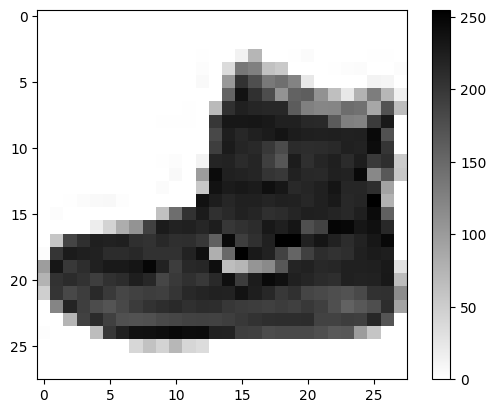

In [21]:
img, label = train_ds[0]
print('图像形状:', img.shape)
print('标签:', label)
print('img:', img)
plt.imshow(transforms.ToPILImage()(img), cmap='binary')
plt.colorbar()
plt.show()

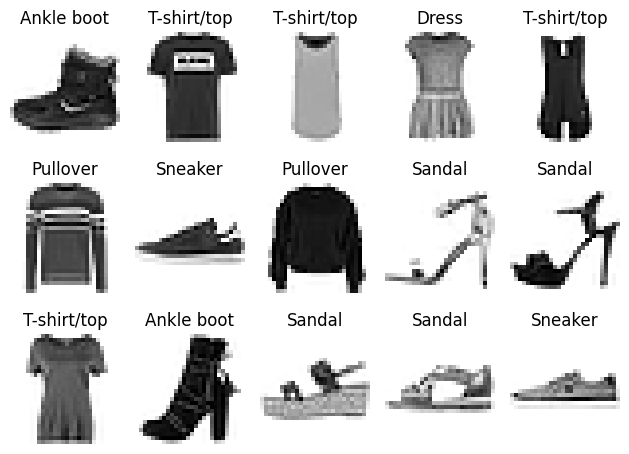

In [22]:
# 可视化前15张图像
for i in range(15):
    img, label = train_ds[i]
    plt.subplot(3, 5, i + 1)
    plt.imshow(transforms.ToPILImage()(img), cmap='binary')
    plt.title(train_ds.classes[label])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [23]:
# 创建数据加载器
# DateLoader是PyTorch中用于加载数据的工具，它提供了批量加载、数据打乱和多线程加载等功能。
# batch_size参数指定每个批次的样本数量，shuffle参数指定是否在每个epoch开始时打乱数据。
# num_workers参数指定用于数据加载的子进程数量，默认为0表示在主进程中加载数据。
# pin_memory参数指定是否将数据加载到固定内存中，这对于使用GPU训练模型时可以提高性能。
train_loader = torch.utils.data.DataLoader(
    train_ds, batch_size=128, shuffle=True, num_workers=0
)
val_loader = torch.utils.data.DataLoader(
    val_ds, batch_size=128, shuffle=False, num_workers=0
)

In [24]:
for data, label in train_loader:
    print('数据批次形状:', data.shape)
    print('标签批次形状:', label.shape)
    break

数据批次形状: torch.Size([128, 1, 28, 28])
标签批次形状: torch.Size([128])


In [25]:
# 参数：在神经网络中，参数是指模型中需要学习的权重和偏置等数值，这些参数会在训练过程中通过反向传播算法进行更新，以最小化损失函数。
# 超参数：在训练神经网络时需要手动设置的参数，如学习率、批次大小、迭代次数等。

# 定义神经网络模型
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()  # 调用父类的构造函数，初始化神经网络模型

        self.flatten = nn.Flatten()  # 将输入的图像数据从二维展平为一维，以便输入到全连接层中

        self.linear_relu_stack = nn.Sequential(  # 定义一个顺序容器，包含多个层和激活函数
            # w 的初始分布是均匀分布，范围是[-sqrt(k), sqrt(k)]，其中k是输入特征的数量。
            nn.Linear(28*28, 512),  # 定义一个全连接层，将输入的784维特征映射到512维特征
            nn.ReLU(),  # 定义一个ReLU激活函数，增加模型的非线性能力
            nn.Linear(512, 256),  # 定义一个全连接层，将输入的512维特征映射到256维特征
            nn.ReLU(),  # 定义一个ReLU激活函数，增加模型的非线性能力
            nn.Linear(256, 10)  # 定义最后一个全连接层，将输入的256维特征映射到10维特征，对应10个类别的输出
        )

    def forward(self, x):
        # x.shape: [batch_size, 1(通道数), 28, 28] -> [batch_size, 28*28]
        x = self.flatten(x)  # 将输入的图像数据展平为一维

        # 将展平后的输入数据通过定义的顺序容器进行前向传播，得到输出的logits（未经过SoftMax函数处理的原始输出）
        logits = self.linear_relu_stack(x)

        return logits


# 创建神经网络模型实例
model = NeuralNetwork()

In [26]:
model

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)

In [27]:
# 计算模型的总参数量
# model.parameters()返回模型中所有可训练参数的迭代器，每个参数都是一个张量。
# p.numel()计算每个参数张量中的元素数量，np.sum()将所有参数的元素数量相加，得到模型的总参数量。

for name, param in model.named_parameters():
    print(f'层名称: {name}, 参数形状: {param.shape}, 参数数量: {param.numel()}')

print('模型总参数量:', np.sum([p.numel() for p in model.parameters()]))

层名称: linear_relu_stack.0.weight, 参数形状: torch.Size([512, 784]), 参数数量: 401408
层名称: linear_relu_stack.0.bias, 参数形状: torch.Size([512]), 参数数量: 512
层名称: linear_relu_stack.2.weight, 参数形状: torch.Size([256, 512]), 参数数量: 131072
层名称: linear_relu_stack.2.bias, 参数形状: torch.Size([256]), 参数数量: 256
层名称: linear_relu_stack.4.weight, 参数形状: torch.Size([10, 256]), 参数数量: 2560
层名称: linear_relu_stack.4.bias, 参数形状: torch.Size([10]), 参数数量: 10
模型总参数量: 535818


In [28]:
# 检查forward方法
for data, label in train_loader:
    output = model(data)  # 将输入数据传递给模型，得到输出的logits
    print('输出形状:', output.shape)  # 输出的形状应该是[batch_size, 10]，对应10个类别的输出
    break

输出形状: torch.Size([128, 10])


In [29]:
# 定义损失函数和优化器

# 交叉熵损失函数适用于多分类问题，它将模型的输出（logits）与实际标签进行比较，计算损失值。
# 内部计算SoftMax函数来将logits转换为概率分布，并计算了实际标签与预测概率分布之间的交叉熵损失。
loss_fn = nn.CrossEntropyLoss()

# 定义优化器，使用随机梯度下降算法
# lr是学习率，控制模型参数更新的步长，过大可能导致训练不稳定，过小可能导致训练过慢。
# momentum是动量参数，帮助加速SGD在相关方向上的收敛，并抑制震荡。
# w 的更新规则是：w = w - lr * dw + momentum * v，其中dw是当前梯度，v是之前的更新值。
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)

In [30]:
@torch.no_grad()  # 在评估模型时，我们不需要计算梯度，因此使用@torch.no_grad()装饰器来禁用梯度计算，以节省内存和加速计算。
def evaluate(model, dataloader, loss_fn):
    loss_list = []  # 存储每个批次的损失值
    pred_list = []  # 存储每个批次的预测标签
    label_list = []  # 存储每个批次的实际标签

    for data, label in dataloader:
        data = data.to(device)  # 将输入数据移动到指定设备（CPU或GPU）
        label = label.to(device)  # 将标签移动到指定设备（CPU或GPU）

        logits = model(data)  # 将输入数据传递给模型，得到输出的logits
        loss = loss_fn(logits, label)  # 计算当前批次的损失值

        # item()方法将单元素张量转换为Python数值，方便存储和计算。
        loss_list.append(loss.item())  # 将当前批次的损失值添加到列表中

        # 获取模型预测的类别标签, argmax函数返回沿指定维度最大值的索引，这里dim=1表示在类别维度上取最大值的索引，即预测的类别标签
        pred = logits.argmax(dim=1)
        # 将预测标签移动到CPU并转换为NumPy数组，添加到列表中
        pred_list.extend(pred.cpu().numpy().tolist())

        # 将实际标签移动到CPU并转换为NumPy数组，添加到列表中
        label_list.extend(label.cpu().numpy().tolist())

    # 计算整体的准确率，使用sklearn的accuracy_score函数比较预测标签和实际标签
    accuracy = accuracy_score(pred_list, label_list)

    # 返回平均损失值和准确率
    return np.mean(loss_list), accuracy

In [31]:
def train(model, train_loader, val_loader, loss_fn, optimizer, epochs, eval_interval=500):
    record_dict = {
        'train': [],
        'val': []
    }

    global_step = 0  # 定义一个全局步骤计数器，用于跟踪训练过程中的总步骤数
    model.train()  # 将模型设置为训练模式，启用dropout和batch normalization等训练特定的行为

    with tqdm(total=epochs * len(train_loader)) as pbar:  # 使用tqdm库创建一个进度条，显示训练的进度
        for epoch in range(epochs):  # 训练指定的轮数
            for data, label in train_loader:
                data = data.to(device)  # 将输入数据移动到指定设备（CPU或GPU）
                label = label.to(device)  # 将标签移动到指定设备（CPU或GPU）

                optimizer.zero_grad()  # 梯度清零，准备进行反向传播

                logits = model(data)  # 前向传播，计算模型的输出logits

                loss = loss_fn(logits, label)  # 计算损失值，比较模型的输出logits与实际标签

                loss.backward()  # 反向传播，计算梯度

                optimizer.step()  # 更新模型参数，使用计算得到的梯度

                pred = logits.argmax(dim=1)  # 获取模型预测的类别标签

                # 计算当前批次的准确率
                acc = accuracy_score(pred.cpu().numpy(), label.cpu().numpy())

                loss = loss.item()  # 将损失值从张量转换为Python数值

                # 记录当前批次的损失值和准确率
                record_dict['train'].append({
                    'step': global_step,
                    'loss': loss,
                    'accuracy': acc
                })

                # 每隔eval_interval步进行一次评估，计算验证集上的损失值和准确率，并记录下来
                if global_step % eval_interval == 0:
                    model.eval()  # 将模型设置为评估模式，禁用dropout和batch normalization等训练特定的行为
                    val_loss, val_acc = evaluate(
                        model, val_loader, loss_fn)  # 在验证集上评估模型，得到损失值和准确率
                    record_dict['val'].append({
                        'step': global_step,
                        'loss': val_loss,
                        'accuracy': val_acc
                    })
                    model.train()  # 将模型切换回训练模式，继续训练

                global_step += 1  # 更新全局步骤计数器
                pbar.update(1)  # 更新进度条
                pbar.set_postfix({'epoch': epoch})  # 在进度条上显示当前的epoch信息

    return record_dict

In [32]:
model = model.to(device)  # 将模型移动到指定设备（CPU或GPU）
record_dict = train(
    model, train_loader, val_loader,
    loss_fn, optimizer, epochs=20, eval_interval=1000
)

100%|██████████| 9380/9380 [01:08<00:00, 137.77it/s, epoch=19]
